In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import sys

In [2]:
root_dir = Path().resolve().parents[0]
data_dir = root_dir / "data" / "rmp_ucsd_reviews.csv"
sys.path.append(str(root_dir))
df = pd.read_csv(data_dir)


In [3]:
COLUMNS_TO_KEEP = [
    "date",
    "class",
    "qualityRating",
    "difficultyRatingRounded",
    "grade",
    "comment",
]
df = df[COLUMNS_TO_KEEP].copy()
valid_course_pattern = r"^[A-Z]{3,}[0-9]+[A-Z]?$"
df = df[df["class"].str.match(valid_course_pattern, na=False)].copy()
df

,date,class,qualityRating,difficultyRatingRounded,grade,comment
1,2014-05-10 14:33:50 +0000 UTC,POLI142A,4,1,NaN,He was a great professor. I loved his lecture ...
2,2013-07-04 17:27:33 +0000 UTC,POLI142A,2,1,NaN,Going to his lectures was pointless. They had ...
3,2013-06-09 04:32:47 +0000 UTC,POLI142A,2,3,NaN,He knows his stuff. But the problem is his a s...
4,2009-06-08 14:11:13 +0000 UTC,INTL190,5,3,NaN,This guy know his stuff. Just come to class pr...
5,2019-05-29 21:54:59 +0000 UTC,POLI104A,3,5,Not sure yet,"Professor Litman has a distinguished resume, b..."
...,...,...,...,...,...,...
38691,2025-03-25 04:59:52 +0000 UTC,PHYS2B,4,4,Not sure yet,Just go to the lectures and actually do the ho...
38692,2025-03-10 22:38:30 +0000 UTC,PHYS2B,5,2,A,Although sometimes his explanations can be vag...
38693,2025-02-10 07:23:16 +0000 UTC,PHYS2B,2,5,Not sure yet,"His lectures are really unclear, he doesn't ex..."
38694,2025-02-02 21:46:01 +0000 UTC,PHYS2A,3,4,B,Tough quizzes that require deep conceptual kno...


In [4]:
df = df.dropna().copy()
df = df.rename(columns={
    "qualityRating": "quality",
    "clarityRatingRounded": "clarity",
    "difficultyRatingRounded": "difficulty",
})
df

,date,class,quality,difficulty,grade,comment
5,2019-05-29 21:54:59 +0000 UTC,POLI104A,3,5,Not sure yet,"Professor Litman has a distinguished resume, b..."
7,2014-03-17 03:16:47 +0000 UTC,MATH194,5,3,A,I love this class and Prof Puha. The material ...
16,2025-09-30 01:13:55 +0000 UTC,MGT175,2,3,B+,"Was not a fan of the 3 hour lectures, and Prof..."
17,2025-03-30 15:24:41 +0000 UTC,MGT175,4,2,A,Attendance is a grade but for us his midterm w...
18,2023-11-17 01:06:28 +0000 UTC,MGT175,2,4,Not sure yet,Very knowledgeable and accomplished individual...
...,...,...,...,...,...,...
38691,2025-03-25 04:59:52 +0000 UTC,PHYS2B,4,4,Not sure yet,Just go to the lectures and actually do the ho...
38692,2025-03-10 22:38:30 +0000 UTC,PHYS2B,5,2,A,Although sometimes his explanations can be vag...
38693,2025-02-10 07:23:16 +0000 UTC,PHYS2B,2,5,Not sure yet,"His lectures are really unclear, he doesn't ex..."
38694,2025-02-02 21:46:01 +0000 UTC,PHYS2A,3,4,B,Tough quizzes that require deep conceptual kno...


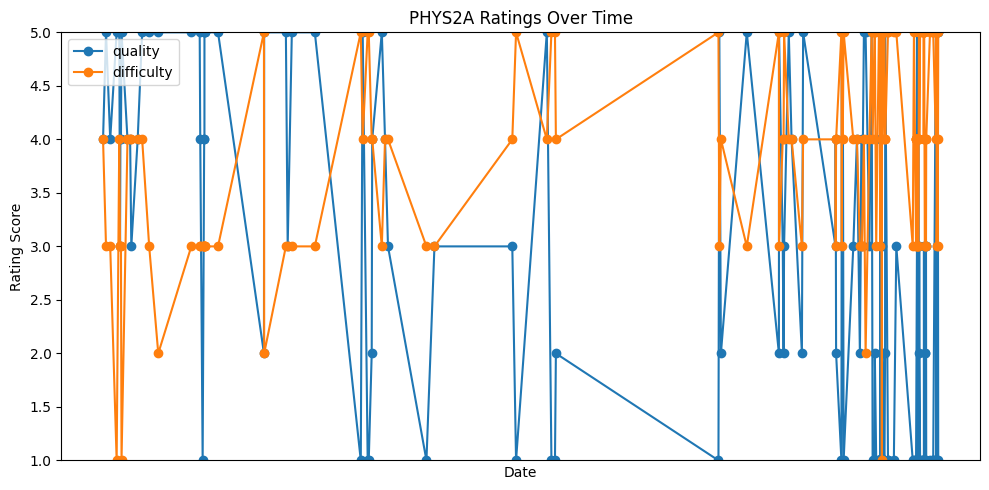

In [5]:
df_clean = df.copy()
df_clean["date"] = df_clean["date"].str.replace(r'\s+UTC$', '', regex=True)
df_clean["date"] = pd.to_datetime(df_clean["date"], utc=True).dt.tz_localize(None)

course = "PHYS2A"
df_course = df_clean[df_clean["class"].str.upper() == course].copy()
df_course = df_course[
    (df_course["date"] >= pd.Timestamp("2016-01-01")) &
    (df_course["date"] <= pd.Timestamp("2026-12-31"))
].sort_values("date").copy()

plt.figure(figsize=(10,5))
plt.plot(df_course["date"], df_course["quality"], marker="o", label="quality")
plt.plot(df_course["date"], df_course["difficulty"], marker="o", label="difficulty")
plt.ylim(1,5)
plt.xlabel("Date")
plt.ylabel("Rating Score")
plt.title("PHYS2A Ratings Over Time")
plt.legend()
plt.xticks([])
plt.tight_layout()
plt.show()

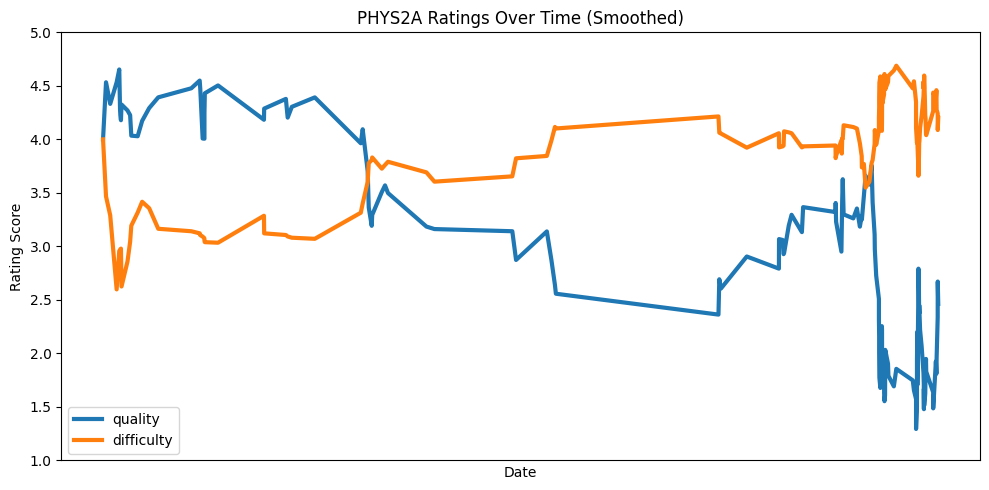

In [6]:
df_smoothed = df_course.copy()
df_smoothed["quality_avg"] = df_smoothed["quality"].ewm(span=15).mean()
df_smoothed["difficulty_avg"] = df_smoothed["difficulty"].ewm(span=15).mean()

plt.figure(figsize=(10,5))
plt.plot(df_smoothed["date"], df_smoothed["quality_avg"], linewidth=3, label="quality")
plt.plot(df_smoothed["date"], df_smoothed["difficulty_avg"], linewidth=3, label="difficulty")
plt.ylim(1,5)
plt.xlabel("Date")
plt.ylabel("Rating Score")
plt.title("PHYS2A Ratings Over Time (Smoothed)")
plt.legend()
plt.xticks([])
plt.tight_layout()
plt.show()

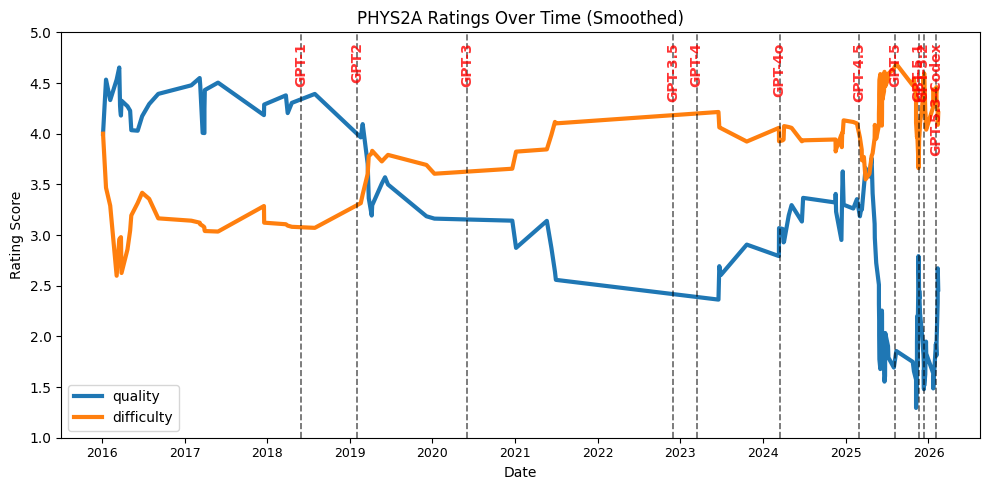

In [7]:
import matplotlib.dates as mdates

releases_df = pd.read_csv(root_dir / "data" / "chatgpt_model_updates.csv")
releases_df["Time"] = pd.to_datetime(releases_df["Time"], format="mixed")
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(df_smoothed["date"], df_smoothed["quality_avg"], linewidth=3, label="quality")
ax.plot(df_smoothed["date"], df_smoothed["difficulty_avg"], linewidth=3, label="difficulty")
ax.set_ylim(1,5)
ax.set_xlabel("Date")
ax.set_ylabel("Rating Score")
ax.set_title("PHYS2A Ratings Over Time (Smoothed)")
ax.legend()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0, ha="center", fontsize=9)

plt.tight_layout()
for _, row in releases_df.iterrows():
    ax.axvline(row["Time"], linestyle="--", linewidth=1.2, alpha=0.6, color="black")
y_top = ax.get_ylim()[1]
for _, row in releases_df.iterrows():
    ax.text(row["Time"], y_top*0.98, row["Model"],
            rotation=90, va="top", ha="center", fontsize=10, alpha=0.8,
            color="red", fontweight="bold")
plt.show()